In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

mpl_params = {
    "text.usetex": True,
    "text.latex.preamble": "\n".join(
        [
            r"\usepackage{bm}",
            r"\usepackage{siunitx}",
            r"\sisetup{detect-all}",
        ]
    ),
    "font.family": "sans-serif",
    "font.sans-serif": "Lato",
    "font.size": 20,
    "legend.frameon": False,
    "axes.linewidth": 2,
    "xtick.major.size": 5,
    "xtick.major.width": 2,
    "ytick.major.size": 5,
    "ytick.major.width": 2,
    "xtick.minor.size": 3,
    "xtick.minor.width": 1.5,
    "ytick.minor.size": 3,
    "ytick.minor.width": 1.5,
}

plt.rcParams.update(mpl_params)
mm2inch = 1e-1 / 2.54

Functions to extract data from LID simulations

In [4]:
def get_data_profiles(folder, duration):
    data = []
    for filename in os.listdir(folder):
        if filename.startswith("profiles") and duration in filename:
            file = open(folder + filename)
            header = file.readline().split("\n")[0]
            file.close()
            header = re.sub("[+]", "", header)

            match_number = re.compile("-?\ *[0-9]+\.?[0-9]*(?:[Ee]\ *-?\ *[0-9]+)?")
            floats = [float(x) for x in re.findall(match_number, header)]
            E = float(floats[0])
            desorbed = float(floats[1])
            data.append([E, desorbed])

    data = np.array(data)
    return data[data[:, 0].argsort()]

def get_data_2D(folder, duration):
    data = []
    for filename in os.listdir(folder):
        if filename.startswith("results") and duration in filename:

            results = np.loadtxt(folder + filename + "/derived_quantities.csv", skiprows=1, delimiter=",")

            t = results[:,0]
            flux = -results[:,1]
            desorbed = np.trapz(flux, x=t)

            match_number = re.compile("-?\ *[0-9]+\.?[0-9]*(?:[Ee]\ *-?\ *[0-9]+)?")
            floats = [float(x) for x in re.findall(match_number, filename)]

            E = float(floats[-1])
            
            data.append([E, desorbed])

    data = np.array(data)
    return data[data[:, 0].argsort()]    

Figure for the OSSFE poster

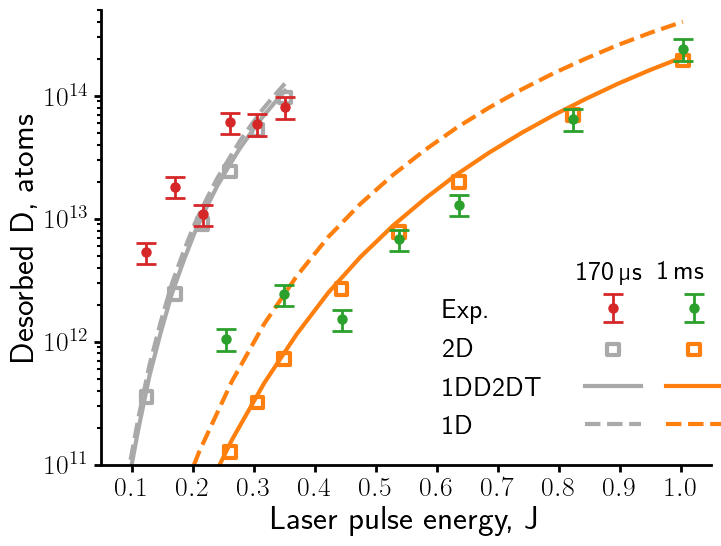

In [ ]:

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(200 * mm2inch, 150 * mm2inch))

exp_data_170us = np.loadtxt("./experimental_data/170 us.csv", skiprows=1, delimiter=",")
exp_data_1ms = np.loadtxt("./experimental_data/1 ms.csv", skiprows=1, delimiter=",")

ax.errorbar(
    exp_data_170us[:, 0],
    exp_data_170us[:, 1],
    yerr=exp_data_170us[:, 1] * 0.20,
    fmt="o",
    markersize=6.5,
    capsize=7.5,
    label="Exp.: 170 us",
    color="tab:red",
    capthick=2,
    lw=2,
    zorder=4
)

ax.errorbar(
    exp_data_1ms[:, 0],
    exp_data_1ms[:, 1],
    yerr=exp_data_1ms[:, 1] * 0.20,
    fmt="o",
    markersize=6.5,
    capsize=7.5,
    label="Exp.: 1 ms",
    color="tab:green",
    capthick=2,
    lw=2,
    zorder=4
)

colors = ["darkgrey", 'tab:orange']

for i, duration in enumerate(["250us", "1ms"]):
    festim_1DD2DT = get_data_profiles("./LID/LID_1DD2DT_results/", duration)
    festim_1D = get_data_profiles("./LID/LID_1D_results/", duration)
    festim_2D = get_data_2D("./LID/LID_2D_results/", duration)

    ax.plot(
        festim_1DD2DT[:, 0],
        festim_1DD2DT[:, 1],
        color=colors[i],
        label="1DD2DT: "+duration,
        lw=3,
        zorder=1
    )

    ax.plot(
        festim_1D[:, 0],
        festim_1D[:, 1],
        label="1D: "+duration,
        color=colors[i],
        ls="dashed",
        lw=3,
        zorder=1
    )

        
    ax.scatter(
        festim_2D[:,0], 
        festim_2D[:,1],
        marker="s",
        s=70,
        label="2D: "+duration,
        edgecolors=colors[i],
        facecolors="none",
        lw=3,
        zorder=3,
        )

extra = Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor="none", linewidth=0)

empty_label = [""]
label_col1 = ["", "Exp.", "2D", "1DD2DT", "1D"]
label_col2 = ["$\SI{170}{\micro\second}$"]
label_col3 = ["$\SI{1}{ms}$"]

h, l = ax.get_legend_handles_labels()

handles = [extra] * 6 + [h[-2]] + [h[2]] + h[0:2] + [extra] + [h[-1]] + [h[-3]] + h[3:5] + [extra]
labels = np.concatenate(
    [label_col1, label_col2, empty_label * 4, label_col3, empty_label * 4]
)
leg = plt.legend(
    handles,
    labels,
    fancybox=False,
    ncols=3,
    handletextpad=-3,
    frameon=False,
    columnspacing=1.5,
    fontsize=20
)
leg.get_texts()[-5].set_ha("right")
leg.get_texts()[-5].set_position((20, 0))
leg.get_texts()[5].set_position((20, 0))
leg.get_texts()[5].set_ha("right")

ax.set_yscale("log")
ax.set_xlim(0.05, 1.05)
ax.set_xticks([i / 10 for i in range(1, 11)])
ax.set_ylim(1e11, 5e14)
ax.set_ylabel(r"Desorbed D, atoms", fontsize=24)
ax.set_xlabel(r"Laser pulse energy, J", fontsize=24)

# plt.savefig("Comparison.svg", bbox_inches="tight", pad_inches=0.1)
plt.show()